# IY025 — catch22 Feature Analysis: Which Features Encode t_ac?

catch22 extracts 22 canonical time-series features. We ask:
1. Which of the 22 features best predict t_ac (autocorrelation time)?
2. After shuffling the time series (destroying temporal structure), do those features still discriminate t_ac?

Features whose scores **decrease** after shuffling are sensitive to temporal autocorrelation structure — not just the marginal count distribution.

In [31]:
import sys
sys.path.insert(0, '../../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm
import pycatch22
import matplotlib.patches as mpatches

from simulation.julia_simulate_telegraph_model import simulate_telegraph_model
from simulation.mean_cv_t_ac import find_tilda_parameters
from utils.steady_state import find_steady_state

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Fixed anchor: μ=1000, CV=0.5 (canonical from IY025 Section 2)
MU       = 1000
CV       = 0.5
TAC_GRID = [3, 6, 10, 15, 22, 30, 40, 50, 65, 80, 100, 120]  # minutes
N_TRAJ   = 200   # trajectories per t_ac
N_PERM   = 100   # permutation iterations

sns.set_theme(style='whitegrid', font='sans-serif')
palette = sns.color_palette('colorblind')

# Autocorrelation-related features (those that directly measure ACF structure)
AC_FEATURES = {
    'CO_f1ecac',                        # first 1/e crossing of autocorrelation
    'CO_FirstMin_ac',                   # first minimum of autocorrelation — closest analogue of t_ac
    'CO_Embed2_Dist_tau_d_expfit_meandiff',  # uses tau from ACF for embedding
    'IN_AutoMutualInfoStats_40_gaussian_fmmi',  # first minimum of auto mutual info
    'FC_LocalSimple_mean1_tauresrat',   # tau from ACF used as ratio
    'SB_TransitionMatrix_3ac_sumdiagcov',       # transition matrix built from ac lag
}

# Print all 22 feature names
FEATURE_NAMES = pycatch22.catch22_all(list(range(100)))['names']
print(f'{len(FEATURE_NAMES)} catch22 features:')
for i, n in enumerate(FEATURE_NAMES):
    marker = '  <-- AC-related' if n in AC_FEATURES else ''
    print(f'  {i:2d}  {n}{marker}')

22 catch22 features:
   0  DN_HistogramMode_5
   1  DN_HistogramMode_10
   2  CO_f1ecac  <-- AC-related
   3  CO_FirstMin_ac  <-- AC-related
   4  CO_HistogramAMI_even_2_5
   5  CO_trev_1_num
   6  MD_hrv_classic_pnn40
   7  SB_BinaryStats_mean_longstretch1
   8  SB_TransitionMatrix_3ac_sumdiagcov  <-- AC-related
   9  PD_PeriodicityWang_th0_01
  10  CO_Embed2_Dist_tau_d_expfit_meandiff  <-- AC-related
  11  IN_AutoMutualInfoStats_40_gaussian_fmmi  <-- AC-related
  12  FC_LocalSimple_mean1_tauresrat  <-- AC-related
  13  DN_OutlierInclude_p_001_mdrmd
  14  DN_OutlierInclude_n_001_mdrmd
  15  SP_Summaries_welch_rect_area_5_1
  16  SB_BinaryStats_diff_longstretch0
  17  SB_MotifThree_quantile_hh
  18  SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1
  19  SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1
  20  SP_Summaries_welch_rect_centroid
  21  FC_LocalSimple_mean3_stderr


### 1. Simulate trajectories

Fixed μ = 1000, CV = 0.5, 200 trajectories per t_ac (same SSA approach as IY025 Section 4). Burn-in is discarded via `find_steady_state`.

In [32]:
def adaptive_T(t_ac, d):
    """Simulation duration: long enough for burn-in and ~30 t_ac cycles, capped at 3000."""
    return int(np.clip(max(2 * (10 / d), 30 * t_ac, 200), 200, 3000))

sim_data = {}  # t_ac -> np.array shape (N_TRAJ, n_timepoints_post_ss)

for t_ac in tqdm(TAC_GRID, desc='Simulating t_ac values'):
    # find parameters
    rho, d, sigma_b, sigma_u = find_tilda_parameters(MU, t_ac, CV)
    parameter_set = [{'sigma_b': sigma_b, 'sigma_u': sigma_u, 'rho': rho, 'd': d, 'label': 0}]
    T = adaptive_T(t_ac, d)
    time_points = np.arange(0, T, 1.0)
    # simulate trajectories
    df_sim = simulate_telegraph_model(parameter_set, time_points, size=N_TRAJ)
    trajs = df_sim.drop(columns='label').values  # (N_TRAJ, T)
    # steady state
    _, ss_idx = find_steady_state(parameter_set[0])
    ss_idx = min(ss_idx, trajs.shape[1] - 1)
    # put steady-state trajectories into dict with corresponding t_ac
    sim_data[t_ac] = trajs[:, ss_idx:]

print('Done. Time series shapes (post burn-in):')
for t_ac, arr in sim_data.items():
    print(f'  t_ac = {t_ac:4d} min   shape = {arr.shape}')

Simulating t_ac values:   0%|          | 0/12 [00:00<?, ?it/s]

Simulating t_ac values: 100%|██████████| 12/12 [00:08<00:00,  1.35it/s]


Done. Time series shapes (post burn-in):
  t_ac =    3 min   shape = (200, 182)
  t_ac =    6 min   shape = (200, 152)
  t_ac =   10 min   shape = (200, 211)
  t_ac =   15 min   shape = (200, 311)
  t_ac =   22 min   shape = (200, 451)
  t_ac =   30 min   shape = (200, 611)
  t_ac =   40 min   shape = (200, 811)
  t_ac =   50 min   shape = (200, 1011)
  t_ac =   65 min   shape = (200, 1311)
  t_ac =   80 min   shape = (200, 1611)
  t_ac =  100 min   shape = (200, 2011)
  t_ac =  120 min   shape = (200, 1811)


### 2. Extract catch22 features

For each trajectory (a 1-D integer time series of mRNA counts), extract all 22 features.

In [33]:
def extract_features(traj_matrix):
    """Extract all 22 catch22 features for every row; returns (n_traj, 22) float array."""
    n = traj_matrix.shape[0]
    feats = np.zeros((n, 22))
    for i, row in enumerate(traj_matrix):
        res = pycatch22.catch22_all(row.tolist())
        feats[i] = res['values']
    return feats

rows = []
for t_ac, arr in tqdm(sim_data.items(), desc='Extracting catch22 features'):
    feats = extract_features(arr)
    for i, f in enumerate(feats):
        rows.append({'t_ac': t_ac, **{FEATURE_NAMES[k]: f[k] for k in range(22)}})

df_feats = pd.DataFrame(rows)
df_feats.to_csv('IY025_catch22_feature_values_by_trajectory.csv', index=False)
print(f'Feature DataFrame shape: {df_feats.shape}')
print('Saved IY025_catch22_feature_values_by_trajectory.csv')
df_feats.head(10)

Extracting catch22 features: 100%|██████████| 12/12 [00:09<00:00,  1.21it/s]

Feature DataFrame shape: (2400, 23)
Saved IY025_catch22_feature_values_by_trajectory.csv


,t_ac,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
0,3,1.102871,0.917836,2.507008,5.0,0.276244,-0.082784,0.950276,14.0,0.011708,...,0.250000,0.153846,0.186813,0.703075,10.0,1.895131,0.195122,0.146341,0.368155,0.882709
1,3,0.600716,-0.702515,1.865480,5.0,0.189044,-0.045976,0.972376,10.0,0.003292,...,0.500000,-0.252747,0.148352,0.509932,9.0,1.889825,0.170732,0.707317,0.564505,1.007434
2,3,1.022972,0.837205,2.634309,13.0,0.256398,-0.051129,0.917127,16.0,0.002066,...,0.250000,0.181319,-0.576923,0.686861,8.0,1.921094,0.512195,0.243902,0.294524,0.853620
3,3,-0.098743,0.089348,2.585097,12.0,0.207975,-0.028734,0.944751,19.0,0.005867,...,0.285714,-0.043956,0.258242,0.682410,9.0,1.838811,0.195122,0.682927,0.343612,0.861193
4,3,0.941527,1.127128,2.862520,14.0,0.224242,-0.097091,0.922652,19.0,0.012397,...,0.250000,-0.010989,0.197802,0.690528,10.0,1.908742,0.170732,0.756098,0.343612,0.834085
5,3,0.834408,1.019128,3.624289,9.0,0.251363,-0.081845,0.928177,22.0,0.046296,...,0.074074,0.000000,0.587912,0.767946,8.0,1.782728,0.146341,0.731707,0.245437,0.765637
6,3,0.519038,1.075031,2.307522,10.0,0.177383,-0.095078,0.961326,15.0,0.012963,...,0.333333,-0.082418,0.032967,0.637963,6.0,1.902009,0.146341,0.829268,0.417243,0.902222
7,3,1.020268,1.189020,2.698312,7.0,0.261167,-0.001215,0.944751,20.0,0.001543,...,0.400000,0.134615,-0.280220,0.717887,8.0,1.854694,0.146341,0.853659,0.343612,0.845055
8,3,-1.267500,-0.774306,2.852887,10.0,0.284719,0.017776,0.906077,19.0,0.015840,...,0.250000,-0.104396,0.164835,0.758863,14.0,1.838811,0.268293,0.146341,0.294524,0.818554
9,3,0.875982,1.072309,2.821653,5.0,0.285099,-0.097254,0.939227,31.0,0.037037,...,0.105263,0.071429,-0.291209,0.679745,10.0,1.869119,0.146341,0.853659,0.319068,0.825744


### 3. Score each feature against t_ac

This section asks whether each catch22 feature changes monotonically with the target autocorrelation time `t_ac`. The score is not an average feature value. Instead, it is the absolute Spearman correlation between one feature's per-trajectory values and the corresponding `t_ac` labels.

Calculation steps:

1. For each `t_ac` in `TAC_GRID`, simulate `N_TRAJ` trajectories.
2. Extract all 22 catch22 feature values from every trajectory. This creates one row per trajectory in `df_feats`.
3. For a given feature, pool all trajectory-level values across all `t_ac` conditions.
4. Compute `Spearman rho(feature values, t_ac labels)`.
5. Plot `|rho|`, so larger bars mean stronger monotonic association with `t_ac`, regardless of whether the feature increases or decreases.

The averaged feature values are used later for the feature-value heatmaps, where the notebook computes the mean feature value at each `t_ac` and then z-scores each feature across `t_ac`.


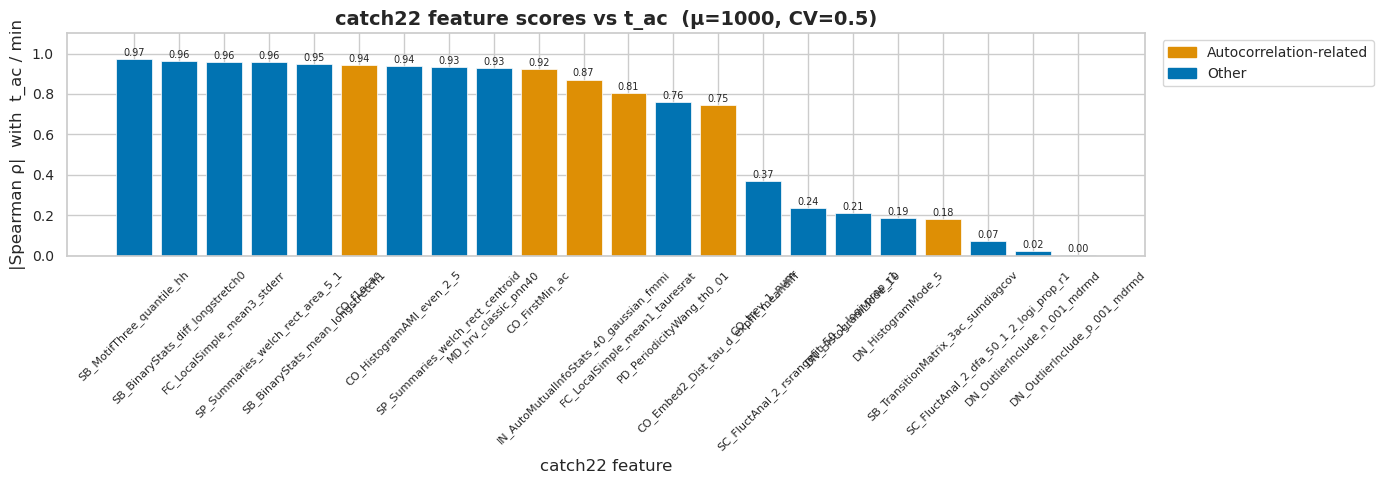

Features:
  1. SB_MotifThree_quantile_hh                     |ρ| = 0.972
  2. SB_BinaryStats_diff_longstretch0              |ρ| = 0.964
  3. FC_LocalSimple_mean3_stderr                   |ρ| = 0.960
  4. SP_Summaries_welch_rect_area_5_1              |ρ| = 0.957
  5. SB_BinaryStats_mean_longstretch1              |ρ| = 0.947
  6. CO_f1ecac                                     |ρ| = 0.943
  7. CO_HistogramAMI_even_2_5                      |ρ| = 0.940
  8. SP_Summaries_welch_rect_centroid              |ρ| = 0.933
  9. MD_hrv_classic_pnn40                          |ρ| = 0.930
  10. CO_FirstMin_ac                                |ρ| = 0.922
  11. IN_AutoMutualInfoStats_40_gaussian_fmmi       |ρ| = 0.871
  12. FC_LocalSimple_mean1_tauresrat                |ρ| = 0.806
  13. PD_PeriodicityWang_th0_01                     |ρ| = 0.761
  14. CO_Embed2_Dist_tau_d_expfit_meandiff          |ρ| = 0.747
  15. CO_trev_1_num                                 |ρ| = 0.371
  16. SC_FluctAnal_2_rsrangefit_50_1_lo

In [34]:
tac_vals = df_feats['t_ac'].values

# Spearman |r| for each feature vs actual t_ac
scores_true = {}
for feat in FEATURE_NAMES:
    vals = df_feats[feat].values
    # Only compute Spearman correlation if there are enough finite values, otherwise set score to 0.0
    finite_mask = np.isfinite(vals)
    if finite_mask.sum() > 10:
        r, _ = stats.spearmanr(tac_vals[finite_mask], vals[finite_mask])
        scores_true[feat] = abs(r)
    else:
        scores_true[feat] = 0.0

# Sort descending
scores_sorted = dict(sorted(scores_true.items(), key=lambda x: x[1], reverse=True))
feat_labels   = list(scores_sorted.keys())
feat_scores   = list(scores_sorted.values())

# --- Bar plot ---
fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = [palette[1] if f in AC_FEATURES else palette[0] for f in feat_labels]
bars = ax.bar(feat_labels, feat_scores, color=bar_colors, edgecolor='white', linewidth=0.5)

for bar, score in zip(bars, feat_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{score:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_ylabel('|Spearman ρ|  with  t_ac / min', fontsize=12)
ax.set_xlabel('catch22 feature', fontsize=12)
ax.set_title(f'catch22 feature scores vs t_ac  (μ={MU}, CV={CV})', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=10)
ax.set_ylim(0, 1.10)

leg_patches = [
    mpatches.Patch(color=palette[1], label='Autocorrelation-related'),
    mpatches.Patch(color=palette[0], label='Other'),
]
ax.legend(handles=leg_patches, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('figures/IY025_catch22_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print('Features:')
for i, (f, s) in enumerate(list(scores_sorted.items())):
    print(f'  {i+1}. {f:45s} |ρ| = {s:.3f}')

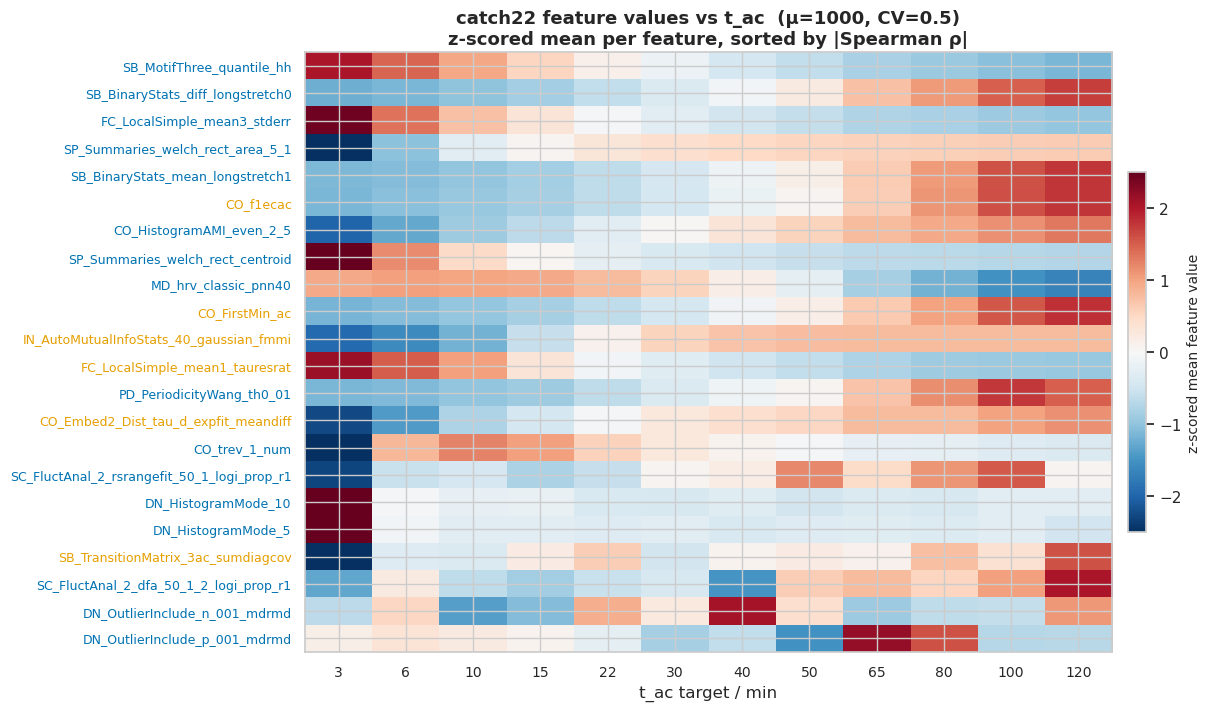

In [35]:
# --- Heatmap of raw feature values (z-scored per feature) vs t_ac ---
# Compute mean feature value per (feature, t_ac)
mean_vals = np.zeros((22, len(TAC_GRID)))
for j, t_ac in enumerate(TAC_GRID):
    sub = df_feats[df_feats['t_ac'] == t_ac]
    for k, feat in enumerate(FEATURE_NAMES):
        vals = sub[feat].values
        finite = vals[np.isfinite(vals)]
        mean_vals[k, j] = finite.mean() if len(finite) > 0 else np.nan

# Z-score each feature across t_ac (row-wise), so colour encodes relative change
from scipy.stats import zscore
mean_z = np.apply_along_axis(
    lambda row: zscore(row) if np.nanstd(row) > 0 else np.zeros_like(row),
    axis=1, arr=mean_vals
)

# Sort rows by Spearman |r| descending (same order as bar chart)
row_order = np.argsort([scores_true[f] for f in FEATURE_NAMES])[::-1]
feat_sorted = [FEATURE_NAMES[i] for i in row_order]
mean_z_sorted = mean_z[row_order]

# Colour rows by AC-related status
row_colors = ['#E69F00' if f in AC_FEATURES else '#0072B2' for f in feat_sorted]

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)
im = ax.imshow(mean_z_sorted, aspect='auto', cmap='RdBu_r', vmin=-2.5, vmax=2.5)

# Axis labels
ax.set_xticks(range(len(TAC_GRID)))
ax.set_xticklabels([str(t) for t in TAC_GRID], fontsize=10)
ax.set_yticks(range(22))
ax.set_yticklabels(feat_sorted, fontsize=9)
ax.set_xlabel('t_ac target / min', fontsize=12)
ax.set_title(f'catch22 feature values vs t_ac  (μ={MU}, CV={CV})\nz-scored mean per feature, sorted by |Spearman ρ|',
             fontsize=13, fontweight='bold')

# Colour y-tick labels to match bar chart palette
for tick, color in zip(ax.get_yticklabels(), row_colors):
    tick.set_color(color)

cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('z-scored mean feature value', fontsize=10)

plt.savefig('figures/IY025_catch22_feature_values_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. Permutation test

For each of {N_PERM} iterations: independently shuffle the time indices of every trajectory, re-extract all 22 catch22 features, and recompute the score.

**What shuffling destroys:** temporal autocorrelation structure (the order of time points).  
**What shuffling preserves:** the marginal distribution of mRNA counts for each trajectory.

Features whose scores **drop** after shuffling rely on temporal order — they are therefore sensitive to autocorrelation dynamics, not just the count distribution.

In [36]:
# Truncate all trajectories to min post-SS length, then stack
min_len    = min(arr.shape[1] for arr in sim_data.values())
all_trajs  = np.vstack([sim_data[t][:, :min_len] for t in TAC_GRID])
all_tac    = np.concatenate(
    [np.full(sim_data[t].shape[0], t) for t in TAC_GRID]
)
print(f'Stacked array shape: {all_trajs.shape}  (min post-SS length = {min_len})')

null_scores = np.zeros((N_PERM, 22))

for perm_i in tqdm(range(N_PERM), desc='Permutation test'):
    # Shuffle time indices independently for each trajectory
    shuffled = np.array([rng.permutation(row) for row in all_trajs])
    # Extract catch22 features
    perm_feats = np.zeros((len(shuffled), 22))
    for i, row in enumerate(shuffled):
        res = pycatch22.catch22_all(row.tolist())
        perm_feats[i] = res['values']
    # Score each feature vs actual t_ac
    for k in range(22):
        vals = perm_feats[:, k]
        finite_mask = np.isfinite(vals)
        if finite_mask.sum() > 10:
            r, _ = stats.spearmanr(all_tac[finite_mask], vals[finite_mask])
            null_scores[perm_i, k] = abs(r)

print(f'Permutation test done. Null score matrix shape: {null_scores.shape}')

Stacked array shape: (2400, 152)  (min post-SS length = 152)


Permutation test: 100%|██████████| 100/100 [02:46<00:00,  1.67s/it]


Permutation test done. Null score matrix shape: (100, 22)


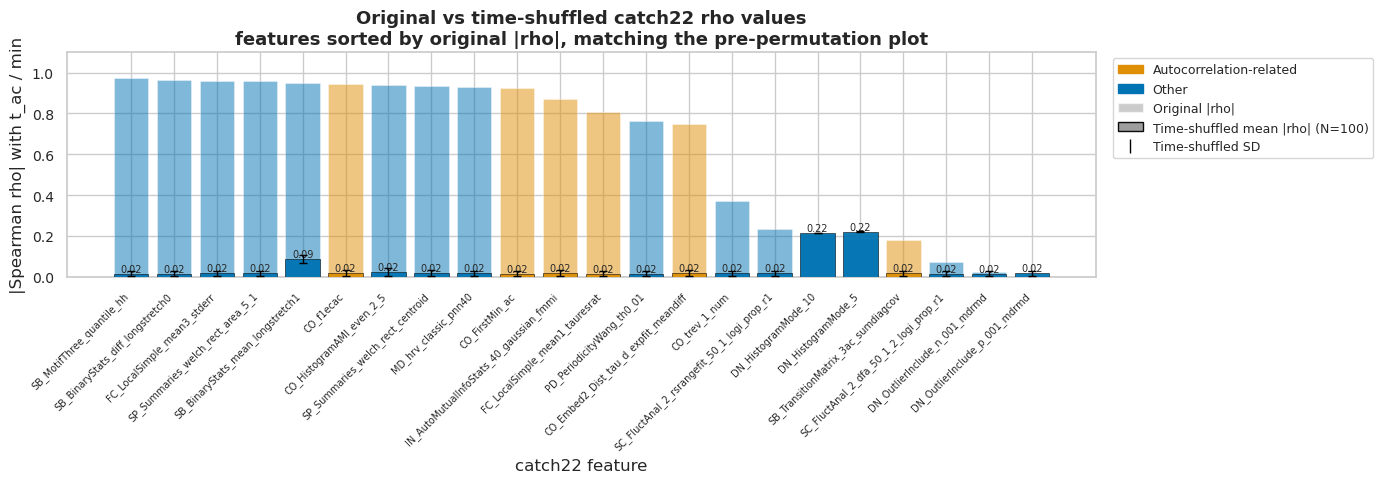

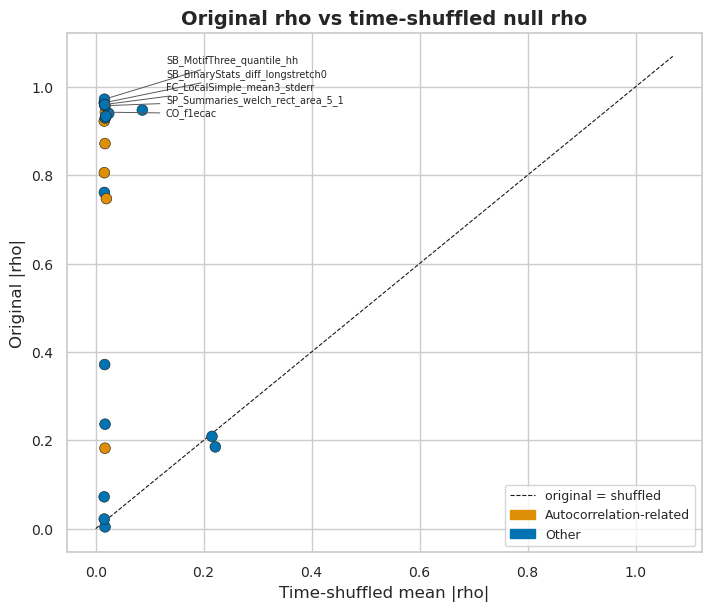

In [37]:
true_arr  = np.array([scores_true[f] for f in FEATURE_NAMES])
null_mean = null_scores.mean(axis=0)
null_std  = null_scores.std(axis=0)
delta     = true_arr - null_mean  # positive = relies on temporal structure

# Use the same feature order as the pre-permutation rho plot: original |rho| descending.
# This keeps the original and post-shuffle bars directly comparable by position.
order        = np.argsort(true_arr)[::-1]
feat_ordered = [FEATURE_NAMES[i] for i in order]
true_ordered  = true_arr[order]
null_mean_ord = null_mean[order]
null_std_ord  = null_std[order]

color_patches = [
    mpatches.Patch(color=palette[1], label='Autocorrelation-related'),
    mpatches.Patch(color=palette[0], label='Other'),
]

# --- Plot 1: original |rho| bars with post-shuffle null bars overlaid ---
fig, ax = plt.subplots(figsize=(14, 5))
x_pos = np.arange(len(feat_ordered))
bar_c = [palette[1] if f in AC_FEATURES else palette[0] for f in feat_ordered]
ax.bar(x_pos, true_ordered, color=bar_c, alpha=0.5,
       edgecolor='white', linewidth=0.5, label='Original |rho|', zorder=2)
ax.bar(x_pos, null_mean_ord, color=bar_c, alpha=0.95,
       edgecolor='black', linewidth=0.4, label=f'Time-shuffled mean |rho| (N={N_PERM})', zorder=3)
ax.errorbar(x_pos, null_mean_ord, yerr=null_std_ord,
            fmt='none', ecolor='black', capsize=3, linewidth=1.0,
            label='Time-shuffled SD', zorder=5)
ax.set_xticks(x_pos)
ax.set_xticklabels(feat_ordered, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('|Spearman rho| with t_ac / min', fontsize=12)
ax.set_xlabel('catch22 feature', fontsize=12)
ax.set_title('Original vs time-shuffled catch22 rho values\nfeatures sorted by original |rho|, matching the pre-permutation plot',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.10)
ax.tick_params(axis='y', labelsize=10)
# show values for the post-shuffle mean |rho| bars
for x, y in zip(x_pos, null_mean_ord):
    ax.text(x, y, f'{y:.2f}', ha='center', va='bottom', fontsize=7)


ax.legend(handles=color_patches + [
    mpatches.Patch(facecolor='0.6', alpha=0.5, edgecolor='white', label='Original |rho|'),
    mpatches.Patch(facecolor='0.6', alpha=0.95, edgecolor='black', label=f'Time-shuffled mean |rho| (N={N_PERM})'),
    plt.Line2D([0], [0], color='black', marker='|', linestyle='none', markersize=10, label='Time-shuffled SD')
], bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('figures/IY025_catch22_permutation_bar.png', dpi=150, bbox_inches='tight', pad_inches=0.25)
plt.show()

# --- Plot 2: original score vs shuffled-null score for each feature ---
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
sc_colors = [palette[1] if f in AC_FEATURES else palette[0] for f in FEATURE_NAMES]
ax.scatter(null_mean, true_arr, c=sc_colors, s=60, edgecolors='k', linewidths=0.4, zorder=3)
lim = max(null_mean.max(), true_arr.max()) * 1.1
ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8, label='original = shuffled')
ax.set_xlabel('Time-shuffled mean |rho|', fontsize=12)
ax.set_ylabel('Original |rho|', fontsize=12)
ax.set_title('Original rho vs time-shuffled null rho', fontsize=14, fontweight='bold')
ax.tick_params(labelsize=10)
ax.legend(handles=[
    plt.Line2D([0], [0], color='k', linestyle='--', linewidth=0.8,
               label='original = shuffled'),
    mpatches.Patch(color=palette[1], label='Autocorrelation-related'),
    mpatches.Patch(color=palette[0], label='Other'),
], loc='best', fontsize=9)

# Annotate the top five features whose rho value drops most after shuffling.
# These cluster tightly near the upper-left, so use fixed label positions and arrows.
top_delta = np.argsort(delta)[::-1][:5]
label_y = np.linspace(1.06, 0.94, len(top_delta))
for idx, y_text in zip(top_delta, label_y):
    ax.annotate(
        FEATURE_NAMES[idx],
        xy=(null_mean[idx], true_arr[idx]),
        xytext=(0.13, y_text),
        textcoords='data',
        fontsize=7,
        arrowprops={'arrowstyle': '-', 'linewidth': 0.7, 'color': '0.35'},
        va='center',
    )

plt.savefig('figures/IY025_catch22_permutation_scatter.png', dpi=150, bbox_inches='tight', pad_inches=0.25)
plt.show()


**How to read the original-vs-shuffled scatter:** each dot is one catch22 feature. The x-axis is the mean absolute Spearman rho after time-shuffling each trajectory, so it measures how much association with `t_ac` remains when temporal order is destroyed. The y-axis is the original absolute Spearman rho before shuffling. Dots near the dashed line keep the same association after shuffling, so they are mostly driven by distributional properties that survive shuffling. Dots far above the dashed line lose rho after shuffling, so their association with `t_ac` depends on temporal ordering/autocorrelation structure.


In [38]:
# Empirical p-value: fraction of permutations where null |r| >= true |r|
p_vals = [(null_scores[:, k] >= true_arr[k]).mean() for k in range(22)]

summary = pd.DataFrame({
    'feature':     FEATURE_NAMES,
    'true_|r|':    true_arr.round(3),
    'null_mean':   null_mean.round(3),
    'null_std':    null_std.round(3),
    'delta':       delta.round(3),
    'p_emp':       p_vals,
    'ac_related':  [f in AC_FEATURES for f in FEATURE_NAMES],
}).sort_values('delta', ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))
summary.to_csv('IY025_catch22_summary.csv', index=False)

                                    feature  true_|r|  null_mean  null_std  delta  p_emp  ac_related
                  SB_MotifThree_quantile_hh     0.972      0.016     0.013  0.956   0.00       False
           SB_BinaryStats_diff_longstretch0     0.964      0.016     0.013  0.948   0.00       False
                FC_LocalSimple_mean3_stderr     0.960      0.017     0.012  0.943   0.00       False
           SP_Summaries_welch_rect_area_5_1     0.957      0.017     0.012  0.940   0.00       False
                                  CO_f1ecac     0.943      0.018     0.014  0.925   0.00        True
                   CO_HistogramAMI_even_2_5     0.940      0.024     0.018  0.916   0.00       False
           SP_Summaries_welch_rect_centroid     0.933      0.019     0.013  0.915   0.00       False
                       MD_hrv_classic_pnn40     0.930      0.018     0.013  0.912   0.00       False
                             CO_FirstMin_ac     0.922      0.016     0.012  0.907   0.00   

Extracting permuted features:   0%|          | 0/2400 [00:00<?, ?it/s]

Extracting permuted features: 100%|██████████| 2400/2400 [00:01<00:00, 1431.76it/s]


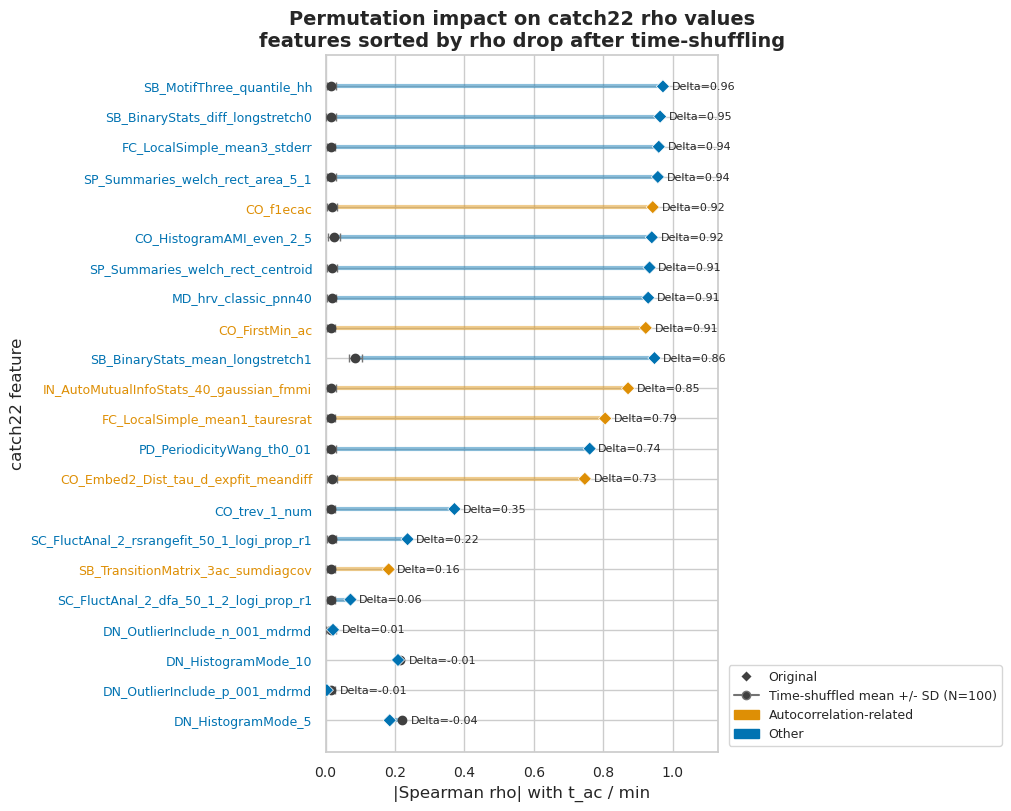

In [39]:
# Run one representative shuffle so the post-permutation feature-value heatmap
# and rho profile come from the same concrete shuffled dataset.
rng_vis = np.random.default_rng(RANDOM_STATE + 99)
shuffled_one = np.array([rng_vis.permutation(row) for row in all_trajs])

# Extract catch22 features from the representative shuffled trajectories.
perm_feats_one = np.zeros((len(shuffled_one), 22))
for i, row in tqdm(enumerate(shuffled_one), total=len(shuffled_one), desc='Extracting permuted features'):
    res = pycatch22.catch22_all(row.tolist())
    perm_feats_one[i] = res['values']

# Mean per (feature, t_ac) from the shuffled data.
perm_mean_vals = np.zeros((22, len(TAC_GRID)))
for j, t_ac in enumerate(TAC_GRID):
    mask = all_tac == t_ac
    sub  = perm_feats_one[mask]
    for k in range(22):
        finite = sub[:, k][np.isfinite(sub[:, k])]
        perm_mean_vals[k, j] = finite.mean() if len(finite) > 0 else np.nan

# Z-score each feature across t_ac, same row order as original heatmap.
perm_mean_z = np.apply_along_axis(
    lambda row: zscore(row) if np.nanstd(row) > 0 else np.zeros_like(row),
    axis=1, arr=perm_mean_vals
)
perm_mean_z_sorted = perm_mean_z[row_order]  # row_order defined in heatmap cell above

# Reindex the permutation-test null distribution to match the original rho
# plot order, so the pre- and post-shuffle rho bars are directly comparable.
feat_name_to_idx = {f: i for i, f in enumerate(FEATURE_NAMES)}
null_mean_by_r = np.array([null_mean[feat_name_to_idx[f]] for f in feat_labels])
null_std_by_r  = np.array([null_std[feat_name_to_idx[f]]  for f in feat_labels])

# --- Plot 1: permutation impact on rho values ---
# Positive delta means the feature's association with t_ac is reduced by time-shuffling.
impact_order = np.argsort(delta)[::-1]
feat_impact = [FEATURE_NAMES[i] for i in impact_order]
true_impact = true_arr[impact_order]
null_impact = null_mean[impact_order]
null_std_impact = null_std[impact_order]
delta_impact = delta[impact_order]

y_pos = np.arange(len(feat_impact))
impact_colors = [palette[1] if f in AC_FEATURES else palette[0] for f in feat_impact]

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
for y, x0, x1, color in zip(y_pos, null_impact, true_impact, impact_colors):
    ax.plot([x0, x1], [y, y], color=color, alpha=0.45, linewidth=3, solid_capstyle='round')
ax.errorbar(null_impact, y_pos, xerr=null_std_impact, fmt='o', color='0.25',
            ecolor='0.45', elinewidth=1.0, capsize=3,
            label=f'Time-shuffled mean +/- SD (N={N_PERM})', zorder=4)
ax.scatter(true_impact, y_pos, marker='D', s=45, color=impact_colors,
           edgecolor='white', linewidth=0.5, label='Original', zorder=5)

for y, d in zip(y_pos, delta_impact):
    ax.text(max(true_impact[y], null_impact[y]) + 0.025, y,
            f'Delta={d:.2f}', va='center', fontsize=8)

ax.set_yticks(y_pos)
ax.set_yticklabels(feat_impact, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('|Spearman rho| with t_ac / min', fontsize=12)
ax.set_ylabel('catch22 feature', fontsize=12)
ax.set_title('Permutation impact on catch22 rho values\nfeatures sorted by rho drop after time-shuffling',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, max(true_impact.max(), (null_impact + null_std_impact).max()) + 0.16)
ax.tick_params(axis='x', labelsize=10)
for tick, color in zip(ax.get_yticklabels(), impact_colors):
    tick.set_color(color)
ax.legend(handles=[
    plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='0.25',
               markersize=6, label='Original'),
    plt.Line2D([0], [0], marker='o', color='0.45', markerfacecolor='0.25',
               markersize=6, label=f'Time-shuffled mean +/- SD (N={N_PERM})'),
    mpatches.Patch(color=palette[1], label='Autocorrelation-related'),
    mpatches.Patch(color=palette[0], label='Other'),
], bbox_to_anchor=(1.01, 0), loc='lower left', fontsize=9)
plt.savefig('figures/IY025_catch22_permutation_impact.png', dpi=150, bbox_inches='tight', pad_inches=0.25)
plt.show()



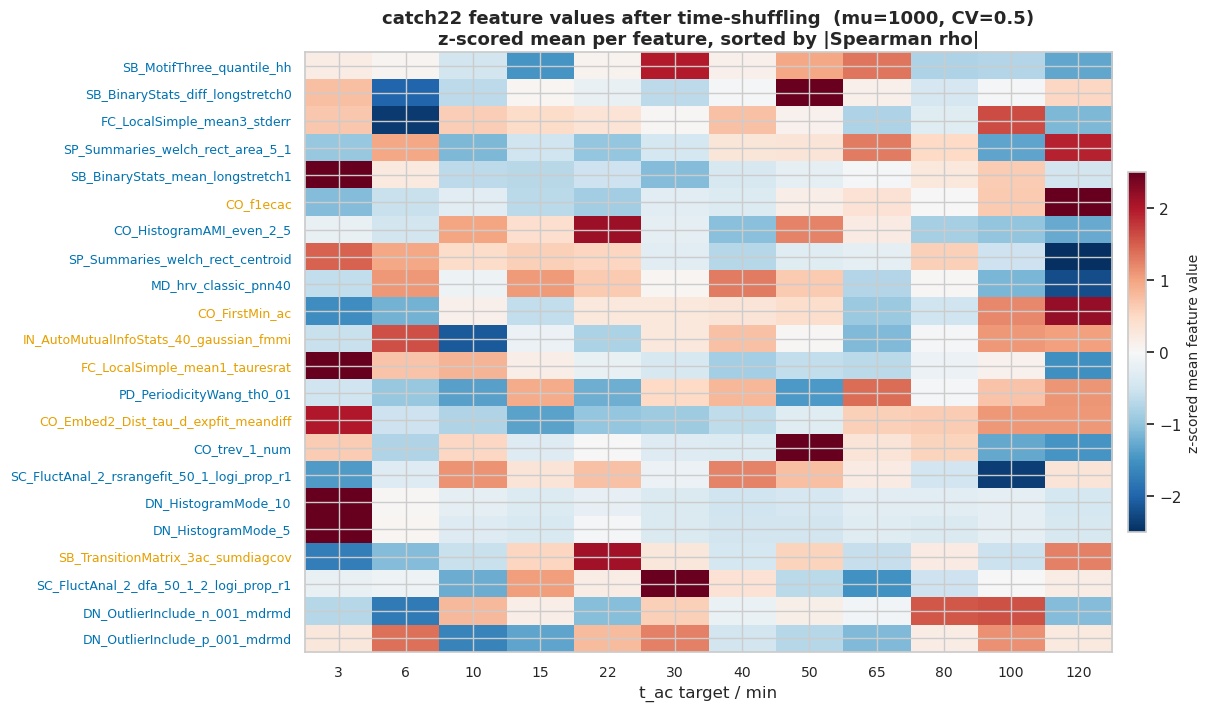

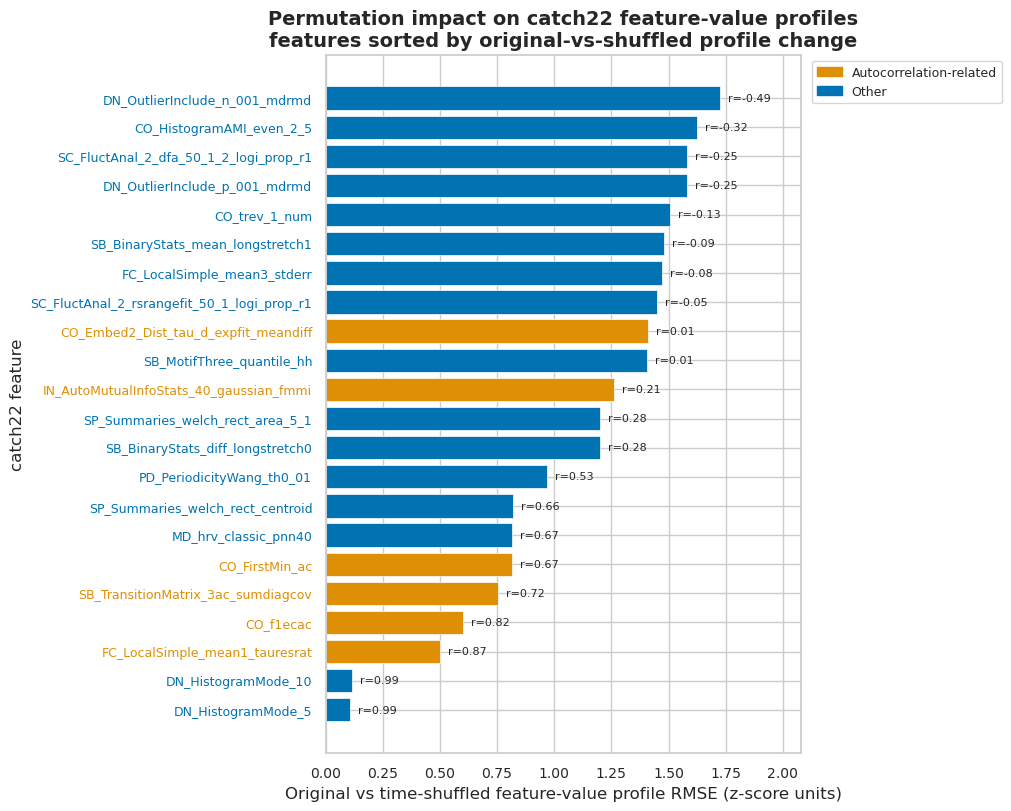

In [40]:
# --- Plot 1: permuted feature values heatmap ---
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)
im = ax.imshow(perm_mean_z_sorted, aspect='auto', cmap='RdBu_r', vmin=-2.5, vmax=2.5)
ax.set_xticks(range(len(TAC_GRID)))
ax.set_xticklabels([str(t) for t in TAC_GRID], fontsize=10)
ax.set_yticks(range(22))
ax.set_yticklabels(feat_sorted, fontsize=9)
ax.set_xlabel('t_ac target / min', fontsize=12)
ax.set_title(f'catch22 feature values after time-shuffling  (mu={MU}, CV={CV})\nz-scored mean per feature, sorted by |Spearman rho|',
             fontsize=13, fontweight='bold')
for tick, color in zip(ax.get_yticklabels(), row_colors):
    tick.set_color(color)
cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('z-scored mean feature value', fontsize=10)
plt.savefig('figures/IY025_catch22_null_feature_values_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: feature-value profile change after time-shuffling ---
# Each feature is represented by its z-scored mean value profile across t_ac.
# RMSE compares the original and shuffled profiles point-by-point across TAC_GRID.
profile_rmse = np.sqrt(np.nanmean((mean_z - perm_mean_z) ** 2, axis=1))
profile_corr = np.zeros(len(FEATURE_NAMES))
for k in range(len(FEATURE_NAMES)):
    finite = np.isfinite(mean_z[k]) & np.isfinite(perm_mean_z[k])
    if finite.sum() > 2 and np.nanstd(mean_z[k, finite]) > 0 and np.nanstd(perm_mean_z[k, finite]) > 0:
        profile_corr[k] = np.corrcoef(mean_z[k, finite], perm_mean_z[k, finite])[0, 1]
    else:
        profile_corr[k] = np.nan

profile_summary = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'profile_rmse_z': profile_rmse,
    'profile_corr': profile_corr,
    'ac_related': [f in AC_FEATURES for f in FEATURE_NAMES],
}).sort_values('profile_rmse_z', ascending=False).reset_index(drop=True)
profile_summary.to_csv('IY025_catch22_feature_value_permutation_profile_change.csv', index=False)

profile_order = np.argsort(profile_rmse)[::-1]
feat_profile = [FEATURE_NAMES[i] for i in profile_order]
rmse_profile = profile_rmse[profile_order]
corr_profile = profile_corr[profile_order]
profile_colors = [palette[1] if f in AC_FEATURES else palette[0] for f in feat_profile]
y_pos = np.arange(len(feat_profile))

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
bars = ax.barh(y_pos, rmse_profile, color=profile_colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_profile, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Original vs time-shuffled feature-value profile RMSE (z-score units)', fontsize=12)
ax.set_ylabel('catch22 feature', fontsize=12)
ax.set_title('Permutation impact on catch22 feature-value profiles\nfeatures sorted by original-vs-shuffled profile change',
             fontsize=14, fontweight='bold')
ax.tick_params(axis='x', labelsize=10)
for tick, color in zip(ax.get_yticklabels(), profile_colors):
    tick.set_color(color)
for bar, corr in zip(bars, corr_profile):
    label = f'r={corr:.2f}' if np.isfinite(corr) else 'r=NA'
    ax.text(bar.get_width() + 0.035, bar.get_y() + bar.get_height() / 2,
            label, va='center', fontsize=8)
ax.set_xlim(0, max(rmse_profile) + 0.35)
ax.legend(handles=[
    mpatches.Patch(color=palette[1], label='Autocorrelation-related'),
    mpatches.Patch(color=palette[0], label='Other'),
], bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.savefig('figures/IY025_catch22_feature_value_permutation_change.png', dpi=150,
            bbox_inches='tight', pad_inches=0.25)
plt.show()

**How to read the feature-value permutation-change plot:** each bar is one catch22 feature. For each feature, the notebook compares the original z-scored mean feature-value profile across `t_ac` with the same profile after time-shuffling. Larger RMSE means the feature-value pattern across `t_ac` changed more after permutation; smaller RMSE means it was preserved. The `r=` label is the correlation between the original and shuffled profiles, so high positive `r` means the shape across `t_ac` is still similar even if the magnitude changed.


### 5. Deep dive on the best feature

Violin plot and median-vs-t_ac trend for the feature with the largest Δ|ρ| (most dependent on temporal autocorrelation structure).

01. SB_MotifThree_quantile_hh: true |rho|=0.972, null mean=0.016, delta=0.956


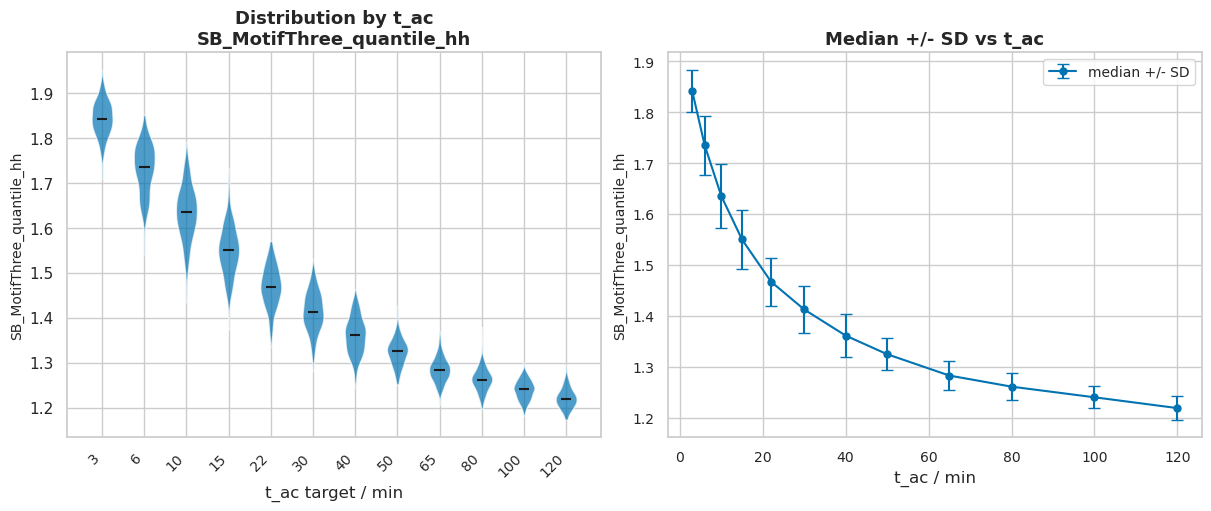

02. SB_BinaryStats_diff_longstretch0: true |rho|=0.964, null mean=0.016, delta=0.948


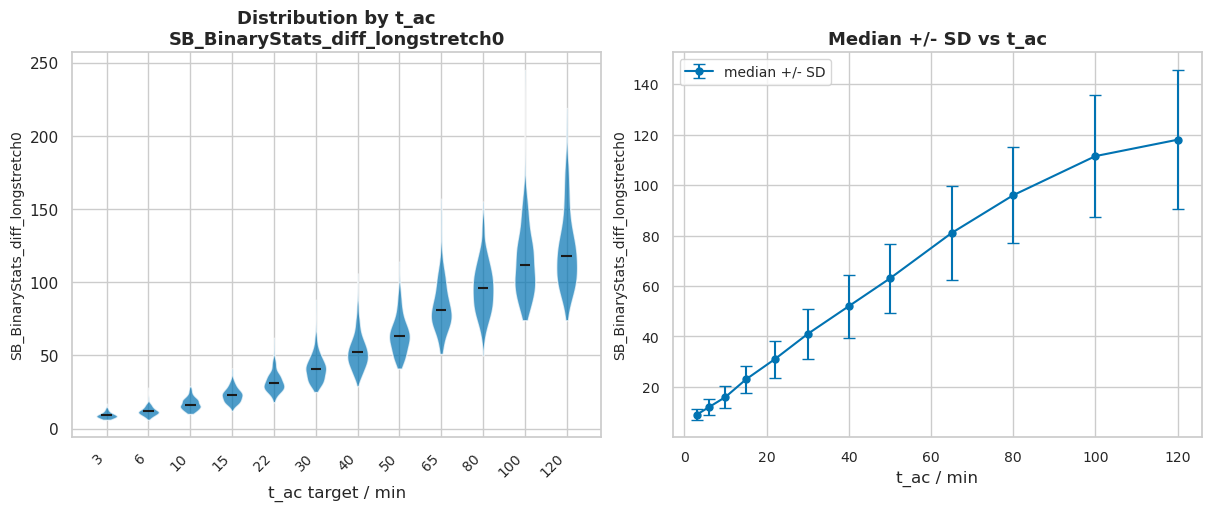

03. FC_LocalSimple_mean3_stderr: true |rho|=0.960, null mean=0.017, delta=0.943


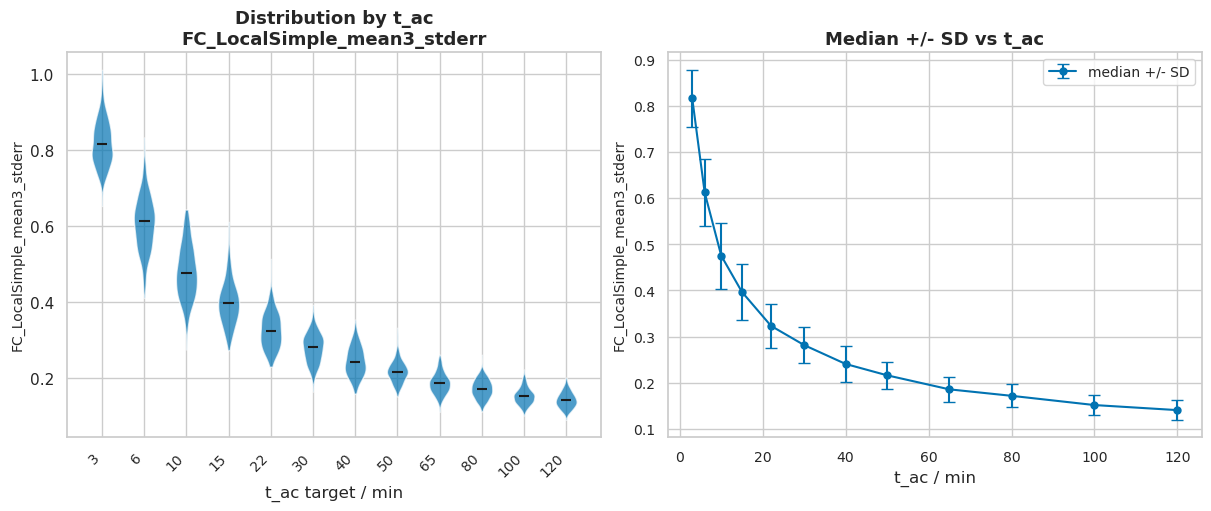

04. SP_Summaries_welch_rect_area_5_1: true |rho|=0.957, null mean=0.017, delta=0.940


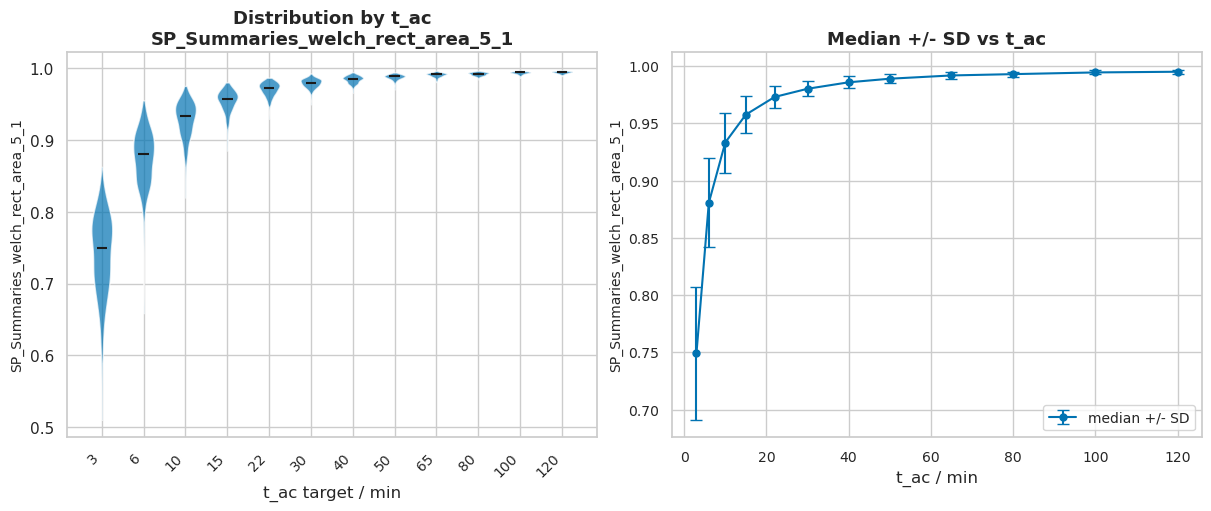

05. CO_f1ecac: true |rho|=0.943, null mean=0.018, delta=0.925


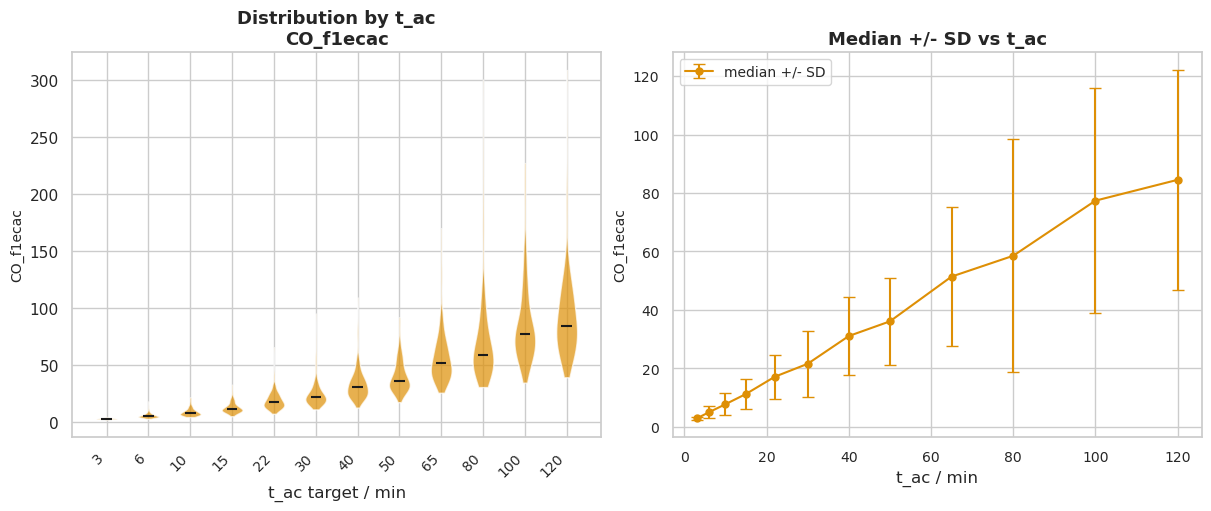

06. CO_HistogramAMI_even_2_5: true |rho|=0.940, null mean=0.024, delta=0.916


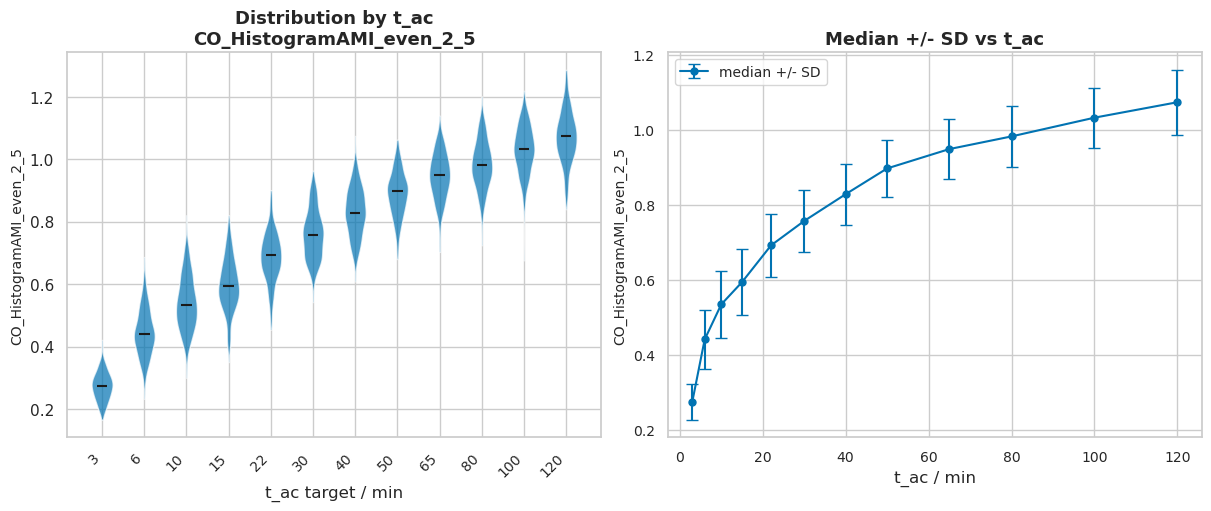

07. SP_Summaries_welch_rect_centroid: true |rho|=0.933, null mean=0.019, delta=0.915


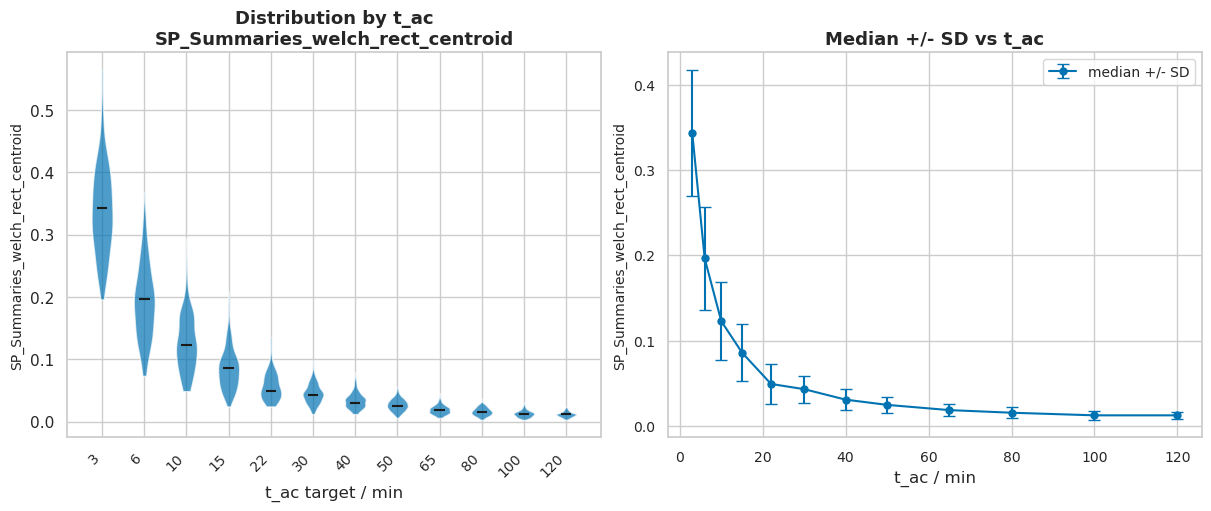

08. MD_hrv_classic_pnn40: true |rho|=0.930, null mean=0.018, delta=0.912


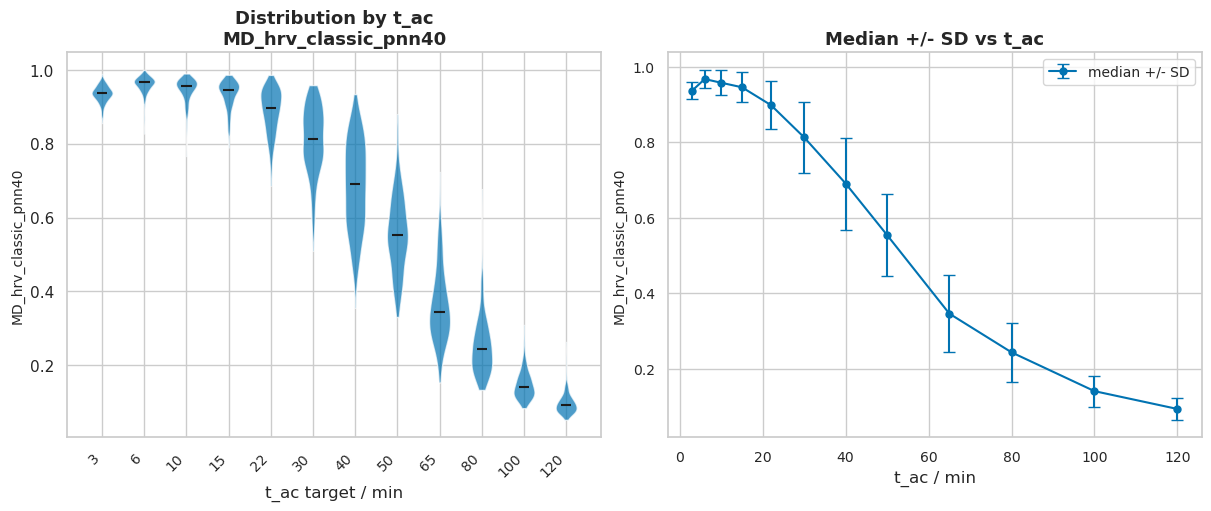

09. CO_FirstMin_ac: true |rho|=0.922, null mean=0.016, delta=0.907


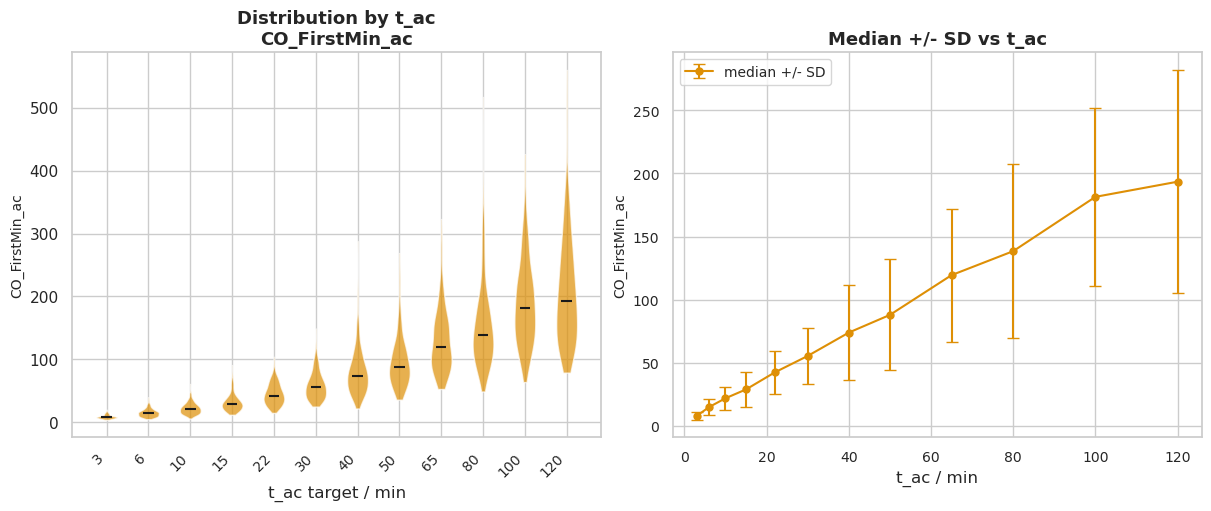

10. SB_BinaryStats_mean_longstretch1: true |rho|=0.947, null mean=0.086, delta=0.861


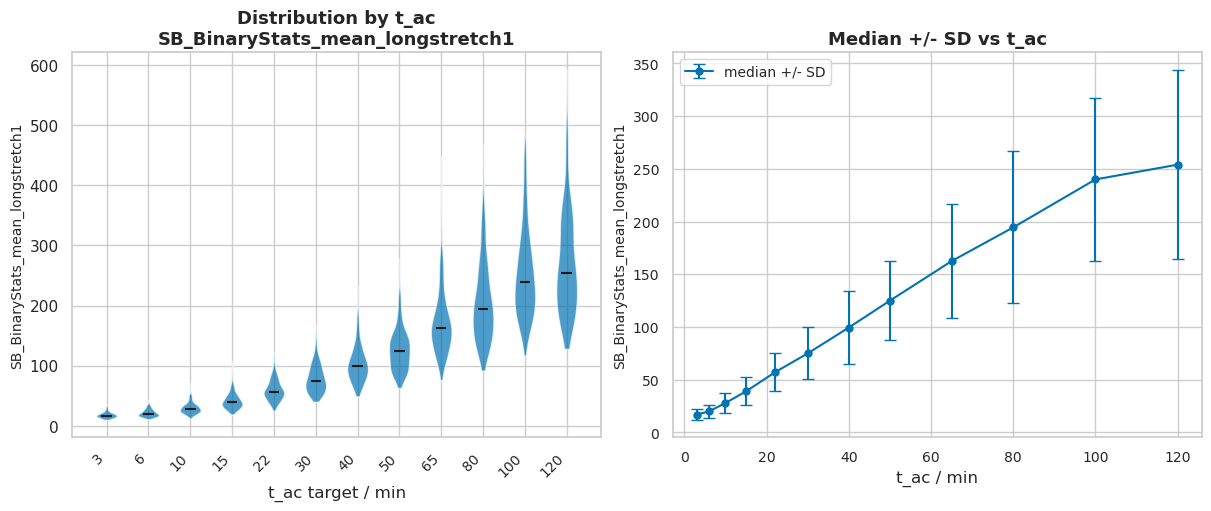

11. IN_AutoMutualInfoStats_40_gaussian_fmmi: true |rho|=0.871, null mean=0.017, delta=0.854


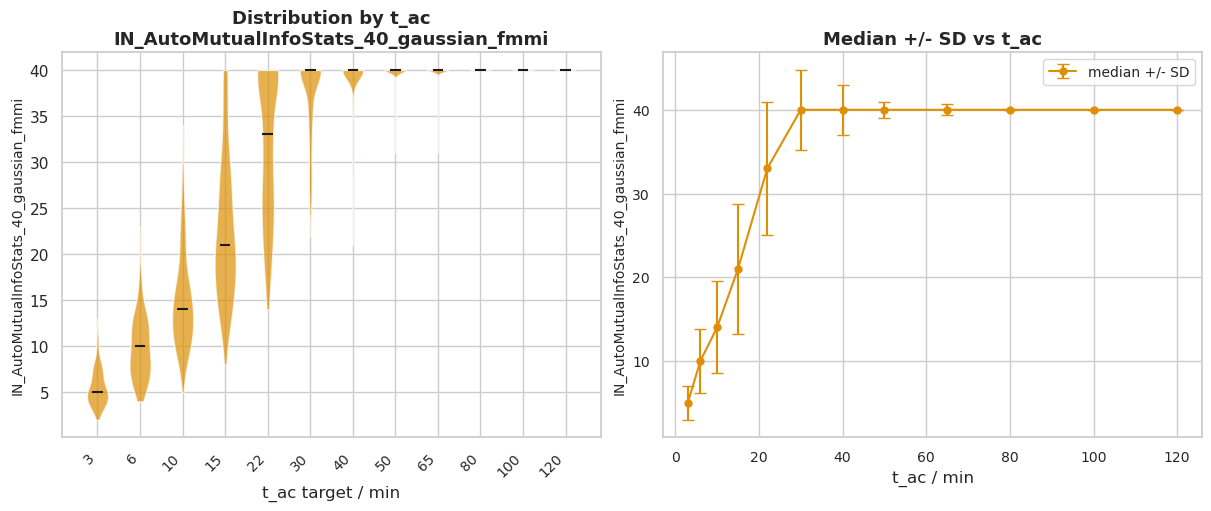

12. FC_LocalSimple_mean1_tauresrat: true |rho|=0.806, null mean=0.016, delta=0.790


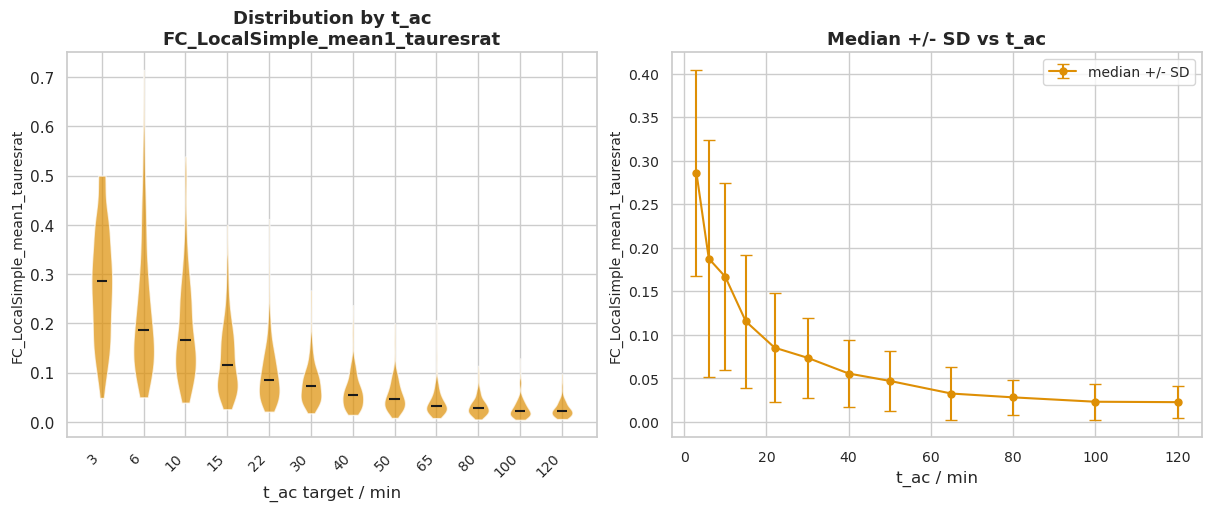

13. PD_PeriodicityWang_th0_01: true |rho|=0.761, null mean=0.016, delta=0.745


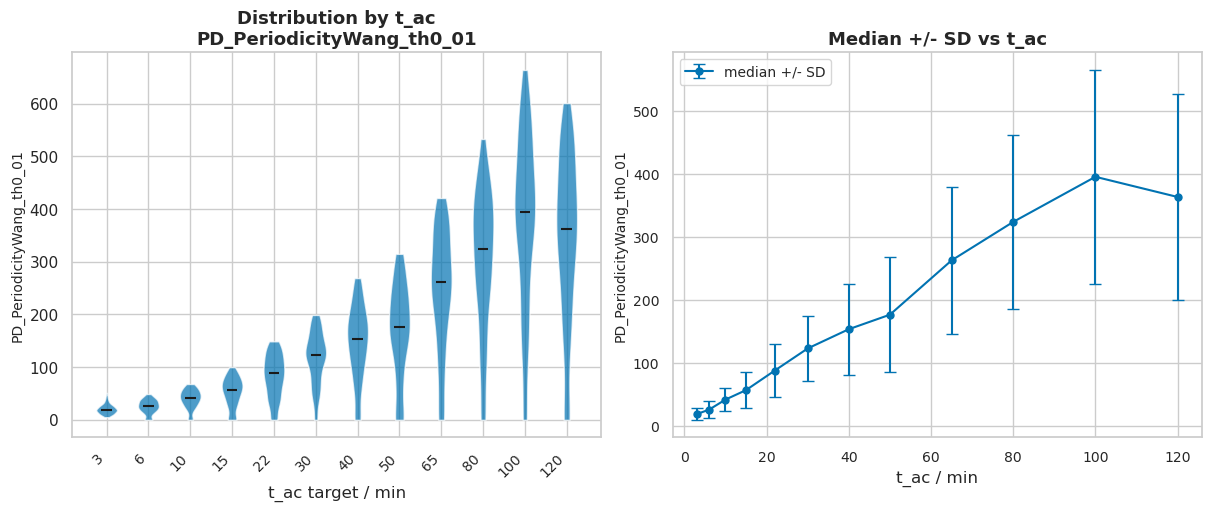

14. CO_Embed2_Dist_tau_d_expfit_meandiff: true |rho|=0.747, null mean=0.020, delta=0.727


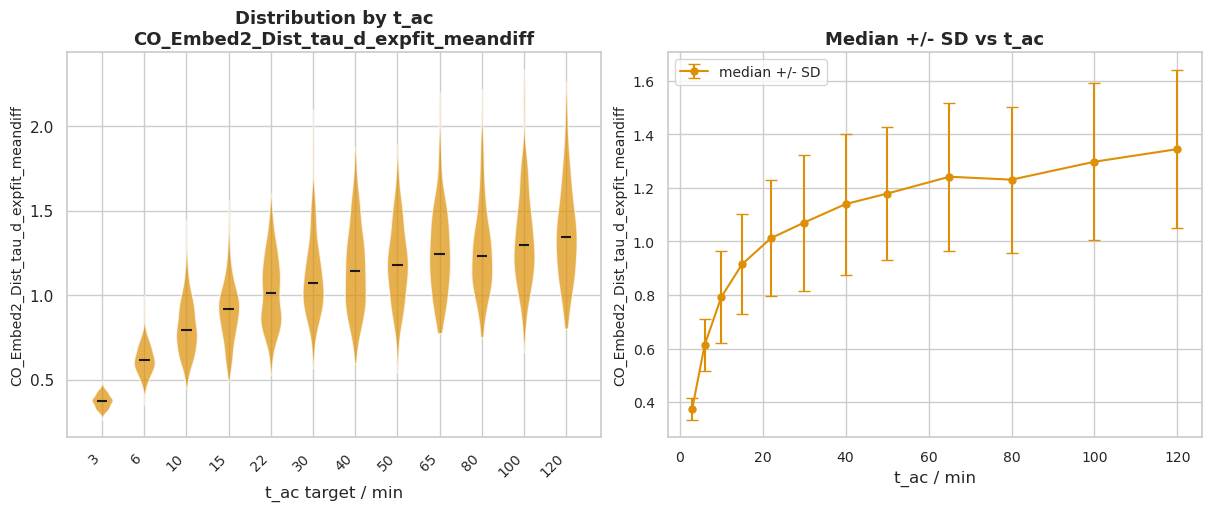

15. CO_trev_1_num: true |rho|=0.371, null mean=0.017, delta=0.355


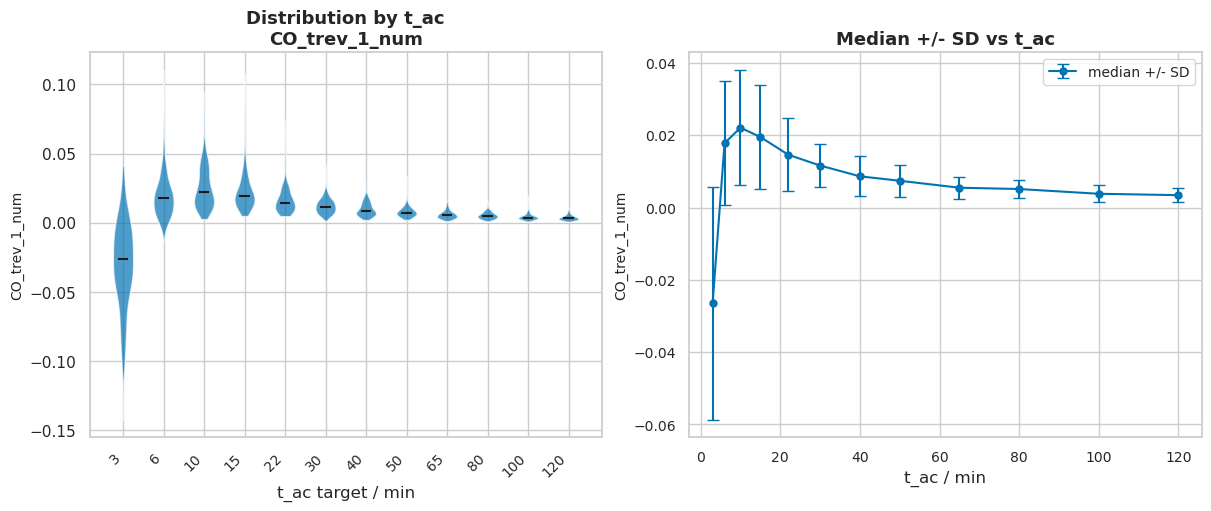

16. SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1: true |rho|=0.236, null mean=0.017, delta=0.219


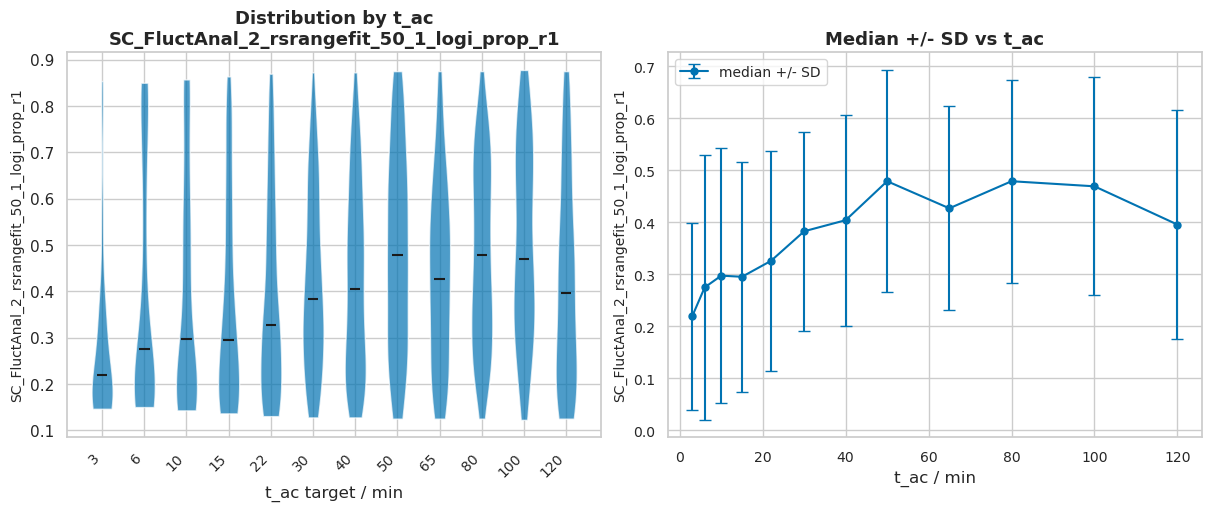

17. SB_TransitionMatrix_3ac_sumdiagcov: true |rho|=0.182, null mean=0.017, delta=0.165


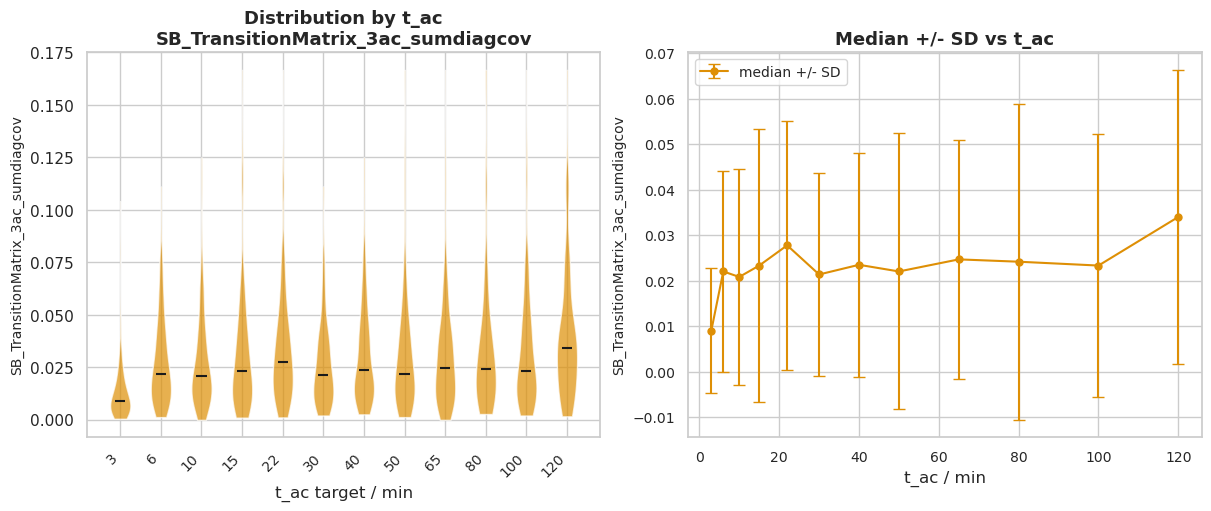

18. SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1: true |rho|=0.072, null mean=0.016, delta=0.056


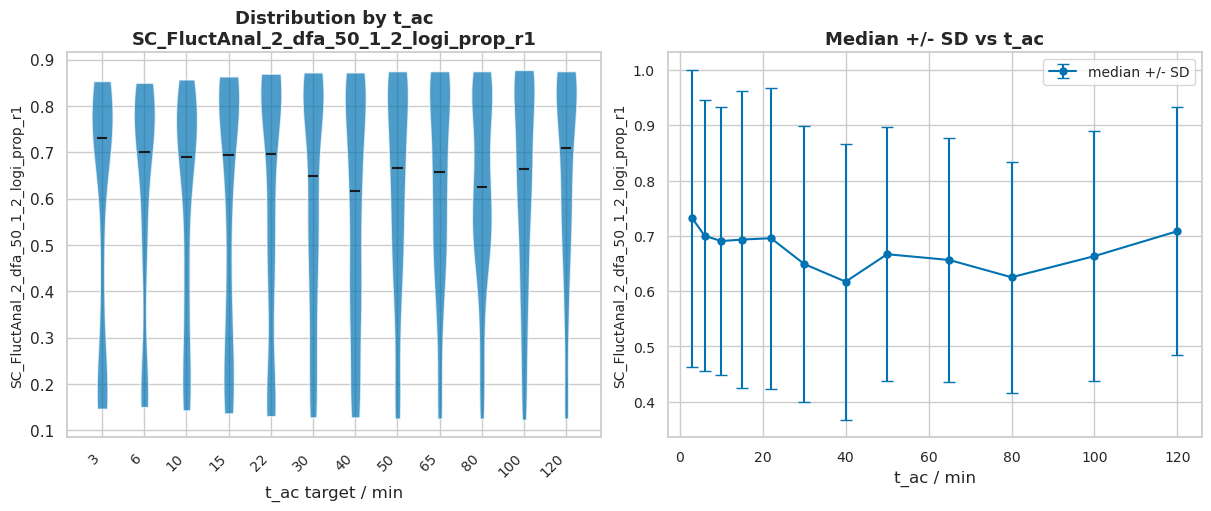

19. DN_OutlierInclude_n_001_mdrmd: true |rho|=0.022, null mean=0.016, delta=0.006


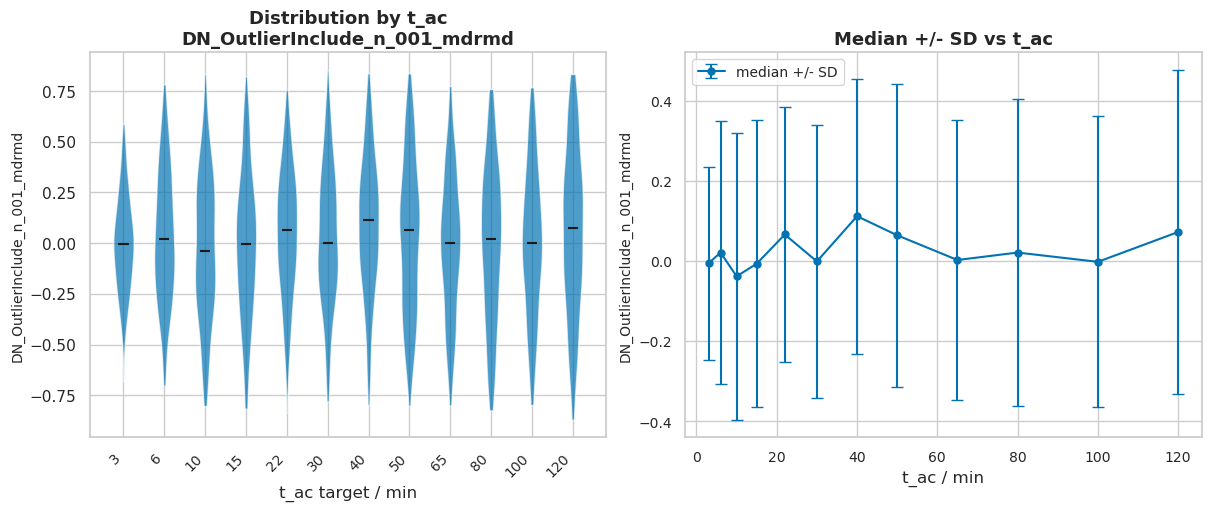

20. DN_HistogramMode_10: true |rho|=0.209, null mean=0.215, delta=-0.007


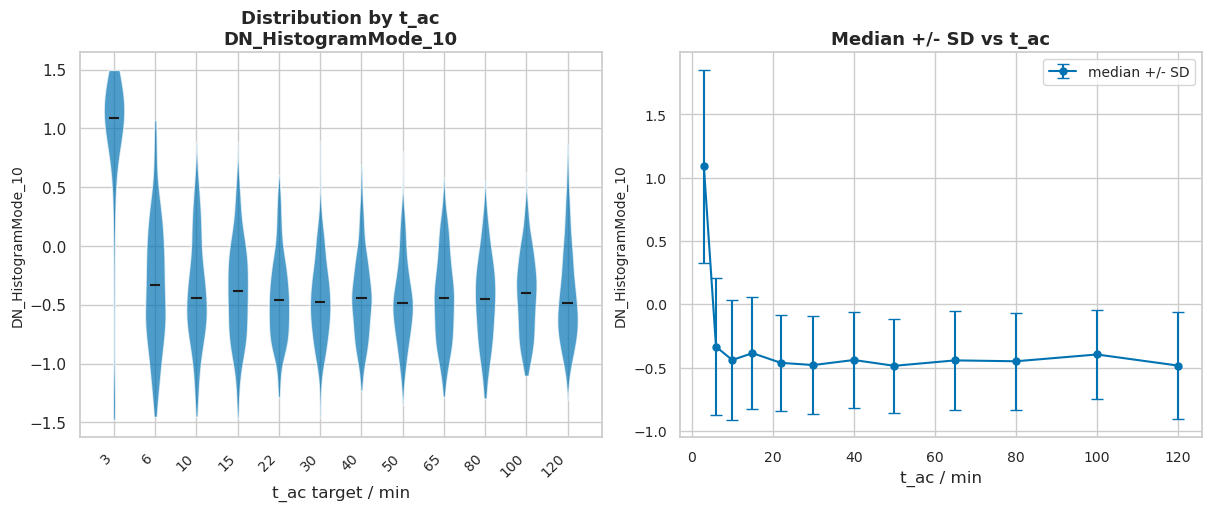

21. DN_OutlierInclude_p_001_mdrmd: true |rho|=0.004, null mean=0.017, delta=-0.013


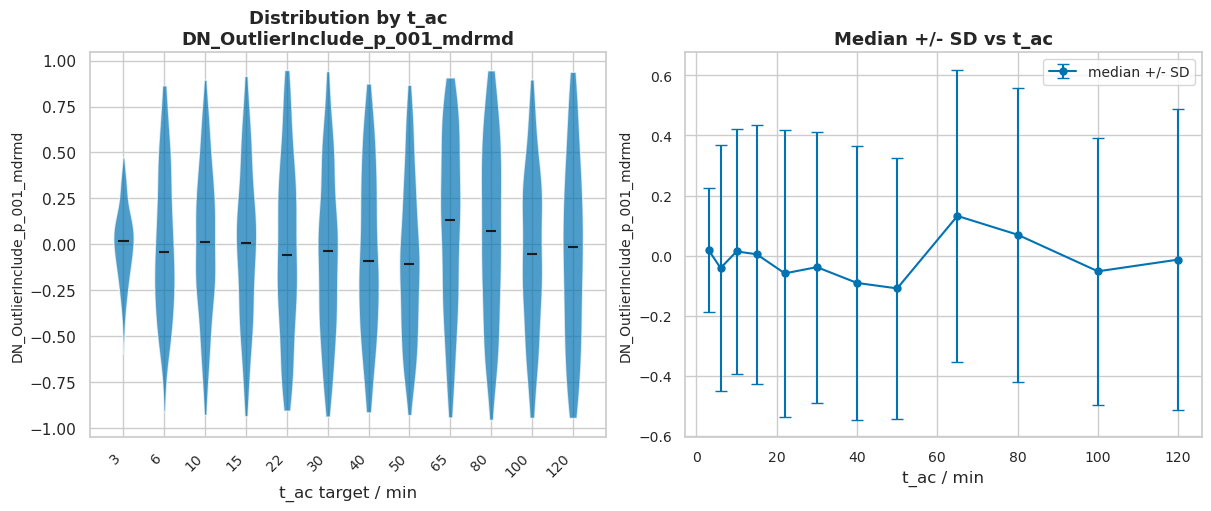

22. DN_HistogramMode_5: true |rho|=0.185, null mean=0.222, delta=-0.037


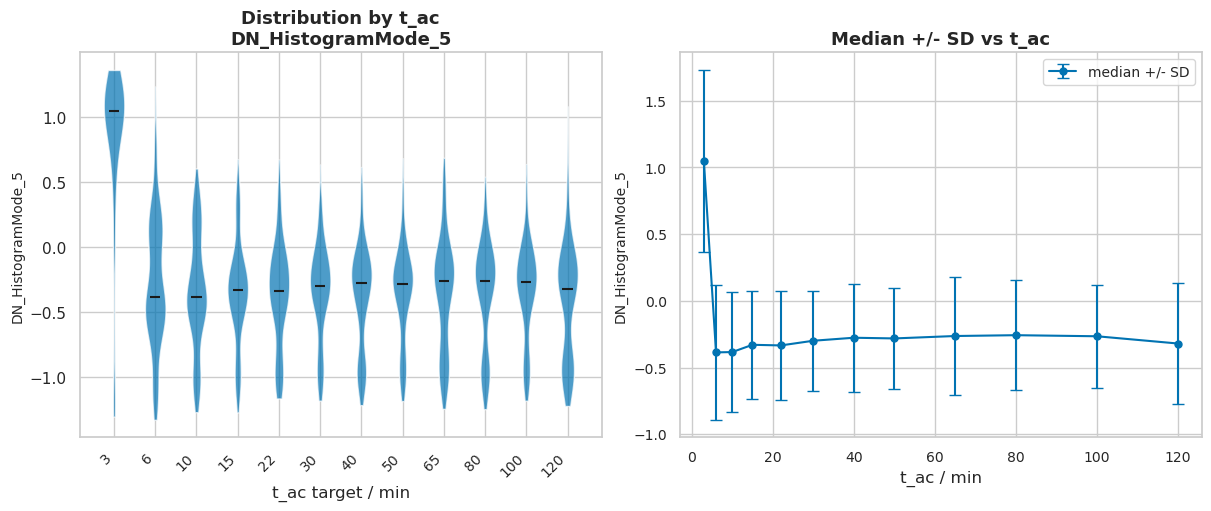

Saved 22 feature distribution figures to figures/IY025_catch22_feature_distributions


In [43]:
from pathlib import Path
deepdive_dir = Path('figures/IY025_catch22_feature_distributions')
deepdive_dir.mkdir(parents=True, exist_ok=True)

# Plot every catch22 feature in the same order as the score summary. Each figure
# mirrors the previous best-feature view: distribution by t_ac on the left and
# median +/- SD against log-scaled t_ac on the right.
feature_order = summary['feature'].tolist()
tac_arr = np.array(TAC_GRID)
deepdive_rows = []

for rank, feat in enumerate(feature_order, start=1):
    row = summary.loc[summary['feature'] == feat].iloc[0]
    print(
        f"{rank:02d}. {feat}: true |rho|={row['true_|r|']:.3f}, "
        f"null mean={row['null_mean']:.3f}, delta={row['delta']:.3f}"
    )

    feat_vals_by_tac = [df_feats[df_feats['t_ac'] == t][feat].values for t in TAC_GRID]
    medians = np.array([np.median(v) for v in feat_vals_by_tac])
    sds = np.array([np.std(v) for v in feat_vals_by_tac])

    for t_ac, median, sd in zip(TAC_GRID, medians, sds):
        deepdive_rows.append({
            'feature': feat,
            'rank_by_delta': rank,
            't_ac': t_ac,
            'median': median,
            'sd': sd,
            'true_abs_rho': row['true_|r|'],
            'null_mean': row['null_mean'],
            'delta': row['delta'],
            'ac_related': row['ac_related'],
        })

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    feature_color = palette[1] if feat in AC_FEATURES else palette[0]

    # Left: distribution per t_ac.
    ax = axes[0]
    parts = ax.violinplot(
        feat_vals_by_tac,
        positions=range(len(TAC_GRID)),
        showmedians=True,
        showextrema=False,
    )
    for pc in parts['bodies']:
        pc.set_facecolor(feature_color)
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('k')
    ax.set_xticks(range(len(TAC_GRID)))
    ax.set_xticklabels([str(t) for t in TAC_GRID], rotation=45, ha='right', fontsize=10)
    ax.set_xlabel('t_ac target / min', fontsize=12)
    ax.set_ylabel(feat, fontsize=10)
    ax.set_title(f'Distribution by t_ac\n{feat}', fontsize=13, fontweight='bold')

    # Right: median +/- SD vs log10(t_ac).
    ax2 = axes[1]
    ax2.errorbar(
        tac_arr,
        medians,
        yerr=sds,
        fmt='o-',
        color=feature_color,
        capsize=4,
        linewidth=1.5,
        markersize=5,
        label='median +/- SD',
    )
    ax2.set_xlabel('t_ac / min', fontsize=12)
    ax2.set_ylabel(feat, fontsize=10)
    ax2.set_title('Median +/- SD vs t_ac', fontsize=13, fontweight='bold')
    ax2.tick_params(labelsize=10)
    ax2.legend(fontsize=10, loc='best')

    safe_feat = feat.replace('/', '_').replace(' ', '_')
    out_path = deepdive_dir / f'IY025_catch22_{rank:02d}_{safe_feat}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')

    # Preserve the old best-feature output path for the top-ranked feature.
    if rank == 1:
        plt.savefig('figures/IY025_catch22_best_feature.png', dpi=150, bbox_inches='tight')

    plt.show()

pd.DataFrame(deepdive_rows).to_csv('IY025_catch22_feature_distribution_summary.csv', index=False)
print(f'Saved {len(feature_order)} feature distribution figures to {deepdive_dir}')
